# 2024 World Happiness Score

In this project, the primary focus is on analyzing the **World Happiness Score** and the key features that influence **Healthy Life Expectancy**, with the goal of understanding how different socio-economic factors contribute to overall well-being.

The World Happiness Score (often represented as the *Ladder score*) reflects how individuals in different countries perceive their quality of life. This score is influenced by several important variables, including **economic performance (Log GDP per capita)**, **social support**, **freedom to make life choices**, **perceptions of corruption**, and **generosity**. Among these, **Healthy Life Expectancy** stands out as a critical component, as it directly reflects the physical well-being and longevity of a population.

This project aims to explore the **relationship between happiness and health**, specifically by:

* Identifying which factors most strongly influence **Healthy Life Expectancy**
* Examining how these factors also contribute to the **overall happiness score**
* Analyzing correlations and patterns across different countries and regions

By leveraging statistical techniques such as **correlation analysis**, **data visualization**, and **predictive modeling**, the project seeks to uncover meaningful insights into how economic, social, and health-related variables interact.

Ultimately, this analysis provides a deeper understanding of:

* Why some countries achieve **higher levels of happiness and health**
* How key indicators like GDP and social support impact **life expectancy**
* The broader connection between **quality of life and national well-being**


The data frame include the following features:

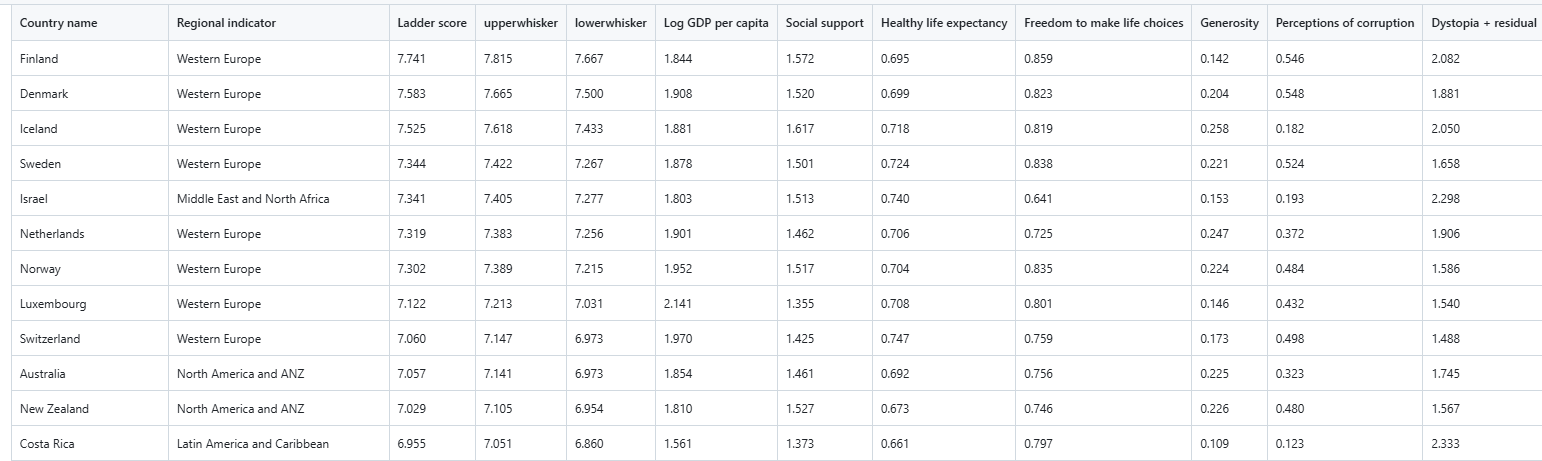

## Load Libraries

In [209]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

## Load the dataset from the storage

In [210]:
url = "https://raw.githubusercontent.com/JoshuaKab/Kaggle_project/main/World-happiness-report-2024.csv"
data = pd.read_csv(url, encoding="latin-1")

data.head()

,Country name,Regional indicator,Ladder score,upperwhisker,lowerwhisker,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual
0,Finland,Western Europe,7.741,7.815,7.667,1.844,1.572,0.695,0.859,0.142,0.546,2.082
1,Denmark,Western Europe,7.583,7.665,7.500,1.908,1.520,0.699,0.823,0.204,0.548,1.881
2,Iceland,Western Europe,7.525,7.618,7.433,1.881,1.617,0.718,0.819,0.258,0.182,2.050
3,Sweden,Western Europe,7.344,7.422,7.267,1.878,1.501,0.724,0.838,0.221,0.524,1.658
4,Israel,Middle East and North Africa,7.341,7.405,7.277,1.803,1.513,0.740,0.641,0.153,0.193,2.298


In [211]:
print(f"Total duplicates value in the dataframe",data.duplicated().sum())

Total duplicates value in the dataframe 0


There's no duplicate value in the dataset, well so we can go streight to data exploratory analysis for fearther exploratory 

In [212]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143 entries, 0 to 142
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country name                  143 non-null    object 
 1   Regional indicator            143 non-null    object 
 2   Ladder score                  143 non-null    float64
 3   upperwhisker                  143 non-null    float64
 4   lowerwhisker                  143 non-null    float64
 5   Log GDP per capita            140 non-null    float64
 6   Social support                140 non-null    float64
 7   Healthy life expectancy       140 non-null    float64
 8   Freedom to make life choices  140 non-null    float64
 9   Generosity                    140 non-null    float64
 10  Perceptions of corruption     140 non-null    float64
 11  Dystopia + residual           140 non-null    float64
dtypes: float64(10), object(2)
memory usage: 13.5+ KB



Most of the features in the dataset are numerical, meaning they consist of quantitative values that can be directly used for statistical analysis and machine learning models. These numerical variables likely represent measurable indicators such as scores, rates, or indices, making them suitable for operations like correlation analysis, normalization, and regression.

In contrast, only two columns—**Country name** and **Regional indicator**—are categorical features. These variables represent qualitative data rather than numerical values. The **Country name** column serves primarily as an identifier for each observation and typically does not contribute directly to predictive modeling unless transformed or encoded. The **Regional indicator** groups countries into broader geographic or socio-economic regions, which can provide useful contextual information but must be converted into a numerical format (e.g., one-hot encoding or label encoding) before being used in most machine learning algorithms.



In [213]:
print("The list of the features that constitutes in the data frame")
data.columns.tolist()

print("The total of null value in the data frame", data.isna().sum())
print("Check the shape of the data frame", data.shape)



The list of the features that constitutes in the data frame
The total of null value in the data frame Country name                    0
Regional indicator              0
Ladder score                    0
upperwhisker                    0
lowerwhisker                    0
Log GDP per capita              3
Social support                  3
Healthy life expectancy         3
Freedom to make life choices    3
Generosity                      3
Perceptions of corruption       3
Dystopia + residual             3
dtype: int64
Check the shape of the data frame (143, 12)


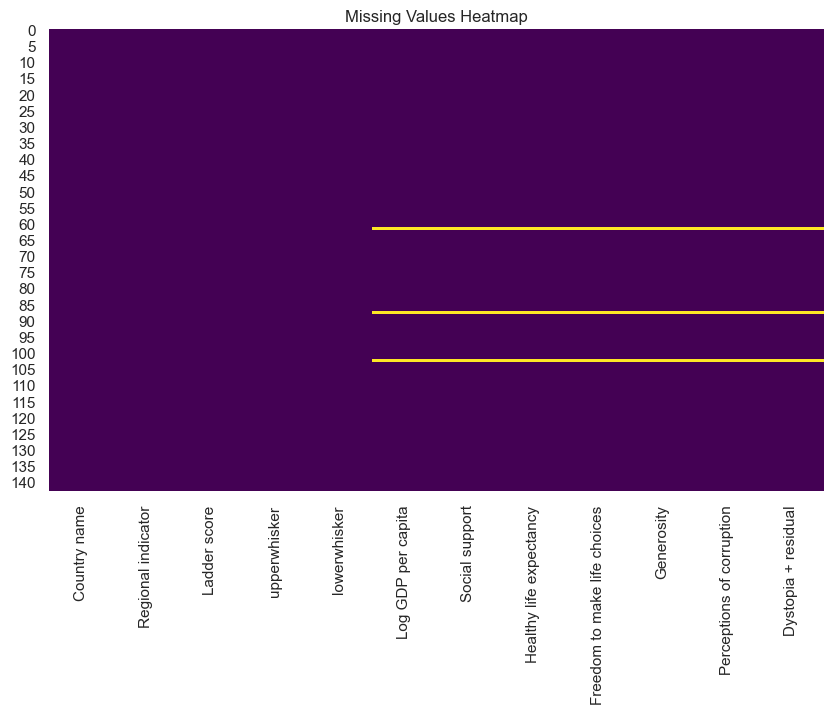

In [214]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [215]:
print("The total number of unique values per column:\n", data.nunique())

The total number of unique values per column:
 Country name                    143
Regional indicator               10
Ladder score                    140
upperwhisker                    140
lowerwhisker                    136
Log GDP per capita              134
Social support                  124
Healthy life expectancy         119
Freedom to make life choices    122
Generosity                      110
Perceptions of corruption       112
Dystopia + residual             134
dtype: int64


### We have two types of data format in the data frame

**2 Calegorical** 

Regional column and Country name 

**10 Numerical**

And the remains columns are numericals   

In [216]:
data.dropna(inplace=True)
print("After removing the null valus let's check again the shape of the data frame",data.shape)

After removing the null valus let's check again the shape of the data frame (140, 12)


In [217]:
duplicates = data.duplicated().sum()

#data['year'] = data['year'].astype(str)

print(f"The total number of duplicates values in dataframe are {duplicates}")

print("The total size remain:", len(data))

The total number of duplicates values in dataframe are 0
The total size remain: 140


We don't have duplicate value in the dataset, the dataset is clean after removing all the null value.

## List of Region indicator

In [218]:
data['Regional indicator'].unique()

array(['Western Europe', 'Middle East and North Africa',
       'North America and ANZ', 'Latin America and Caribbean',
       'Central and Eastern Europe', 'Southeast Asia', 'East Asia',
       'Commonwealth of Independent States', 'Sub-Saharan Africa',
       'South Asia'], dtype=object)

## List of Countries name

In [219]:
data["Country name"].unique()

array(['Finland', 'Denmark', 'Iceland', 'Sweden', 'Israel', 'Netherlands',
       'Norway', 'Luxembourg', 'Switzerland', 'Australia', 'New Zealand',
       'Costa Rica', 'Kuwait', 'Austria', 'Canada', 'Belgium', 'Ireland',
       'Czechia', 'Lithuania', 'United Kingdom', 'Slovenia',
       'United Arab Emirates', 'United States', 'Germany', 'Mexico',
       'Uruguay', 'France', 'Saudi Arabia', 'Kosovo', 'Singapore',
       'Taiwan Province of China', 'Romania', 'El Salvador', 'Estonia',
       'Poland', 'Spain', 'Serbia', 'Chile', 'Panama', 'Malta', 'Italy',
       'Guatemala', 'Nicaragua', 'Brazil', 'Slovakia', 'Latvia',
       'Uzbekistan', 'Argentina', 'Kazakhstan', 'Cyprus', 'Japan',
       'South Korea', 'Philippines', 'Vietnam', 'Portugal', 'Hungary',
       'Paraguay', 'Thailand', 'Malaysia', 'China', 'Honduras', 'Croatia',
       'Greece', 'Bosnia and Herzegovina', 'Libya', 'Jamaica', 'Peru',
       'Dominican Republic', 'Mauritius', 'Moldova', 'Russia', 'Bolivia',
       'Ecua

## Exoloratory Data Analaysis(EDA)

#### Discriptive Analysis

In [220]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Ladder score,140.0,5.530893,1.181247,1.721,4.63175,5.8005,6.42625,7.741
upperwhisker,140.0,5.644057,1.165108,1.775,4.76225,5.9110,6.51525,7.815
lowerwhisker,140.0,5.417700,1.198051,1.667,4.50375,5.6765,6.33825,7.667
Log GDP per capita,140.0,1.378807,0.425098,0.000,1.07775,1.4315,1.74150,2.141
Social support,140.0,1.134329,0.333317,0.000,0.92175,1.2375,1.38325,1.617
Healthy life expectancy,140.0,0.520886,0.164923,0.000,0.39800,0.5495,0.64850,0.857
Freedom to make life choices,140.0,0.620621,0.162492,0.000,0.52750,0.6410,0.73600,0.863
Generosity,140.0,0.146271,0.073441,0.000,0.09100,0.1365,0.19250,0.401
Perceptions of corruption,140.0,0.154121,0.126238,0.000,0.06875,0.1205,0.19375,0.575
Dystopia + residual,140.0,1.575914,0.537459,-0.073,1.30825,1.6445,1.88175,2.998


Plot distribution of the all numerical column with histoplot method techniques

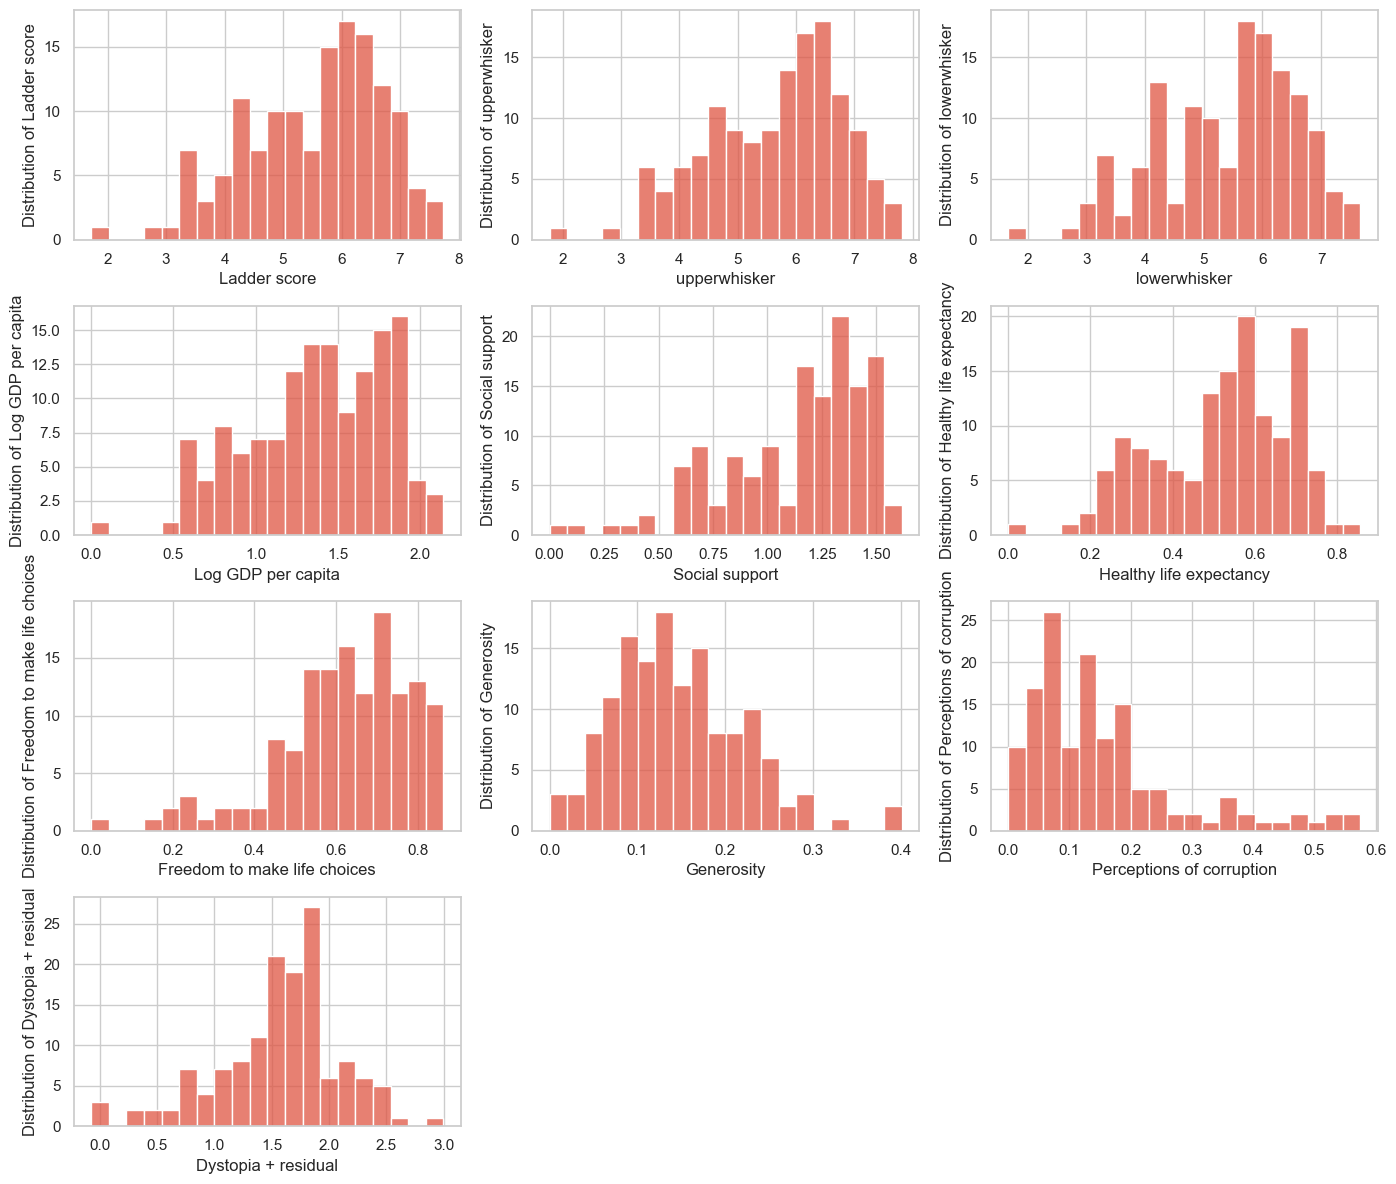

In [221]:
numerical_features = data.select_dtypes(include='number').columns # to get numberic features

#Plot histplot of all numerical columns 
sns.set_style("whitegrid")

plt.figure(figsize=(14,12))

# Loop through numerical features
for i, column in enumerate(numerical_features, start=1):  # Use enumerate to get the index
    plt.subplot(4, 3, i)  # Adjust the number of rows and columns as needed
    sns.histplot(data[column], bins=20, kde=False, color="#DF5543")
    plt.xlabel(column)
    plt.ylabel(f'Distribution of {column}')

plt.tight_layout()
plt.show()

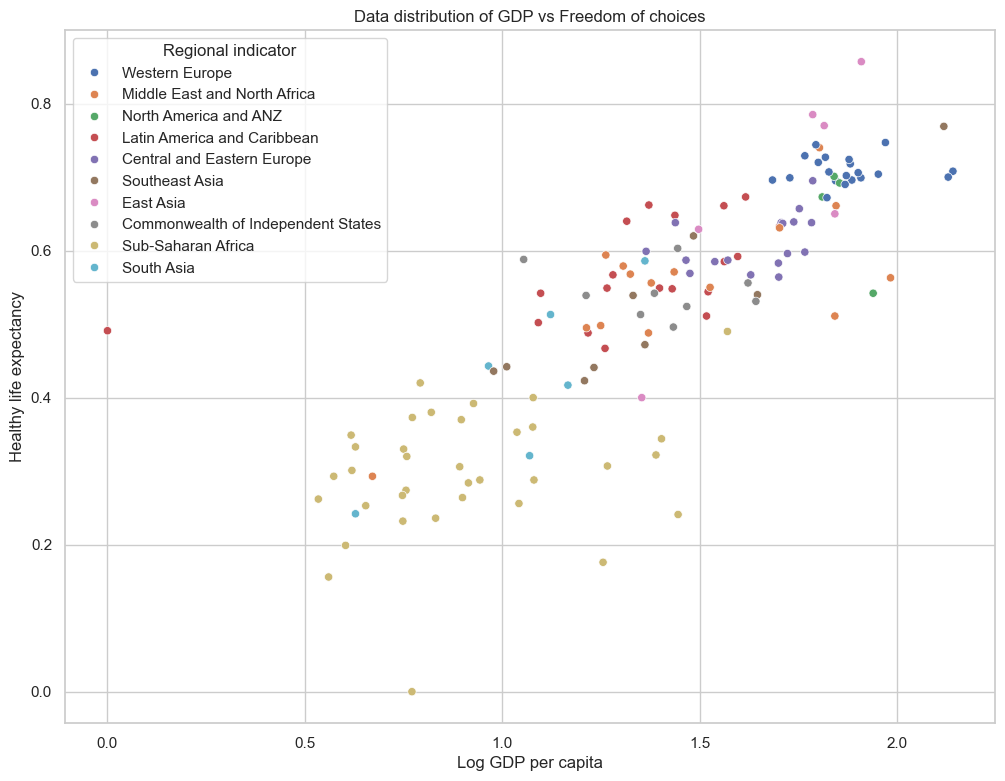

In [222]:
plt.figure(figsize=(12,9))
sns.scatterplot(data=data, x='Log GDP per capita', y='Healthy life expectancy', hue="Regional indicator")
plt.title("Data distribution of GDP vs Freedom of choices")
plt.show()

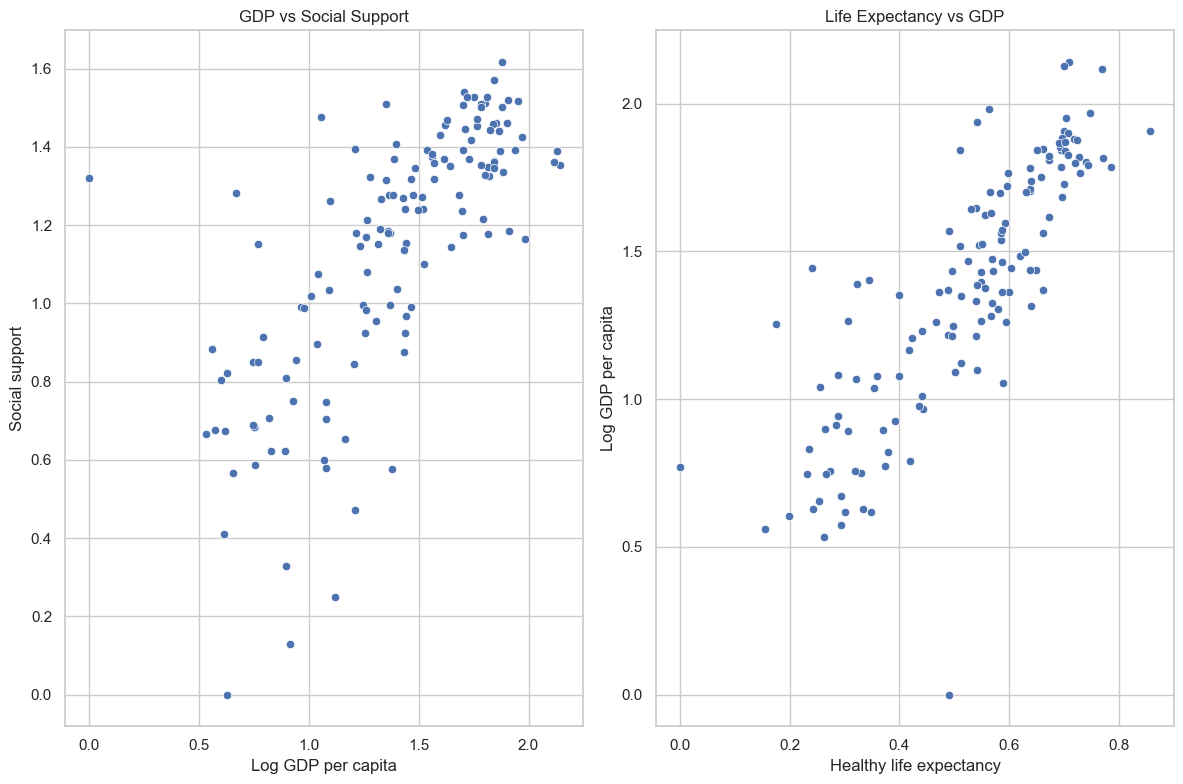

In [223]:
fig, ax = plt.subplots(1, 2, figsize=(12, 8))

# First plot
sns.scatterplot(
    data=data,
    x='Log GDP per capita',
    y='Social support',
    #hue='Regional indicator',
    ax=ax[0]
)
ax[0].set_title("GDP vs Social Support")

# Second plot
sns.scatterplot(
    data=data,
    x='Healthy life expectancy',
    y='Log GDP per capita',
    #hue='Regional indicator',
    ax=ax[1]
)
ax[1].set_title("Life Expectancy vs GDP")

plt.tight_layout()
plt.show()

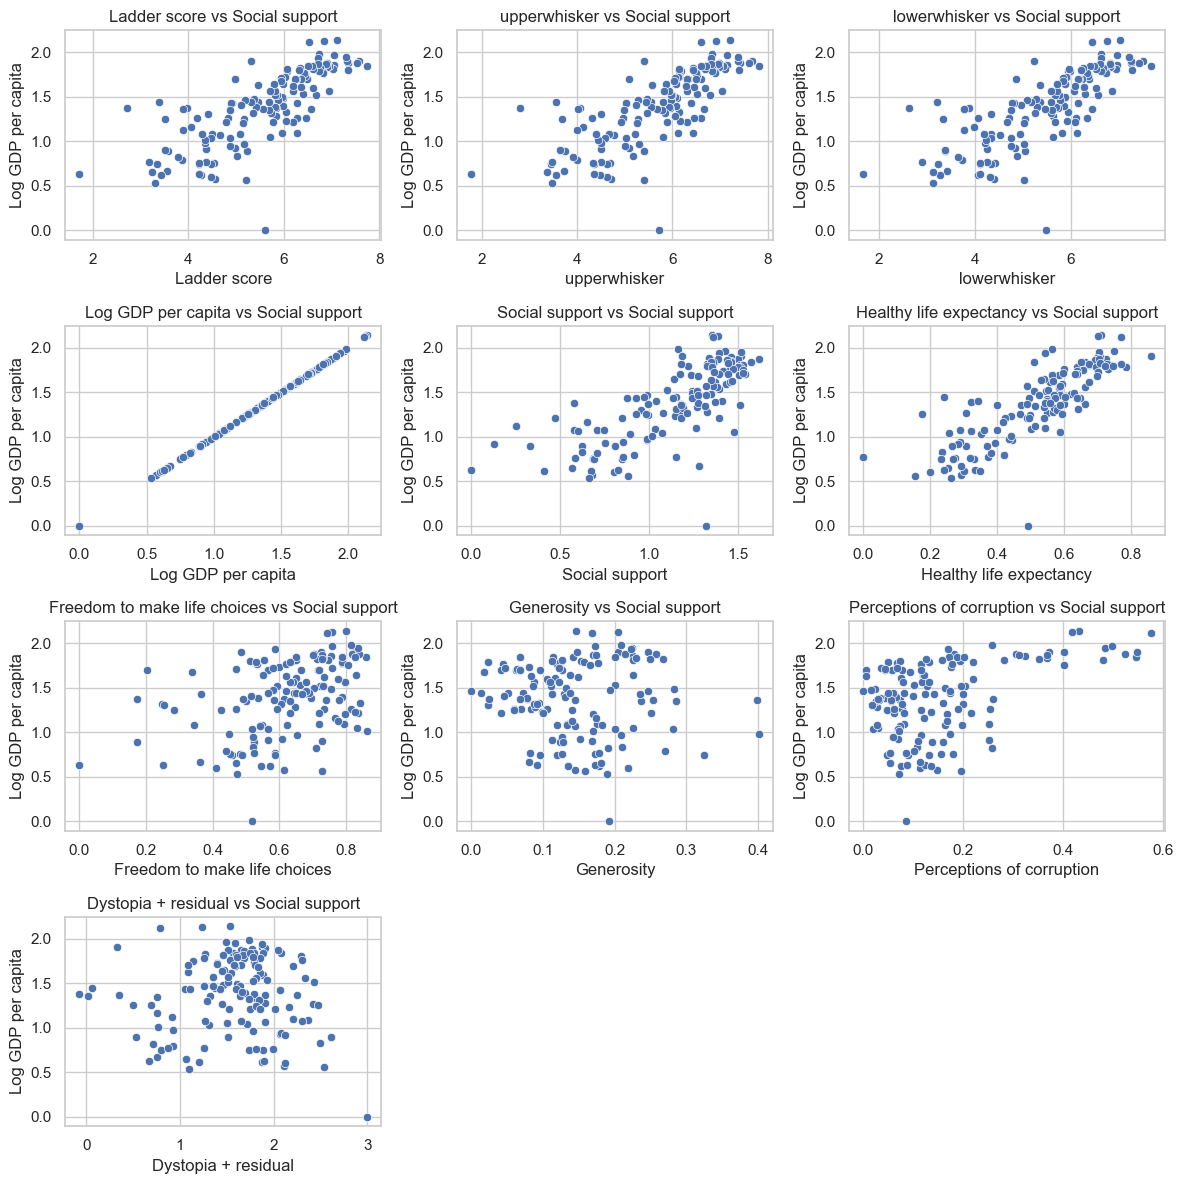

In [224]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = data.describe(exclude='object').columns

plt.figure(figsize=(12, 12))

for i, col in enumerate(cols, 1):  # start index at 1
    plt.subplot(4, 3, i)
    sns.scatterplot(data=data, x=col, y='Log GDP per capita')
    plt.title(f"{col} vs Social support")

plt.tight_layout()
plt.show()

C:\Users\Joshua\AppData\Local\Temp\ipykernel_13824\2329213646.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top5_by_region = data.groupby('Regional indicator').apply(lambda x: x.nlargest(5, 'Healthy life expectancy')).reset_index(drop=True)


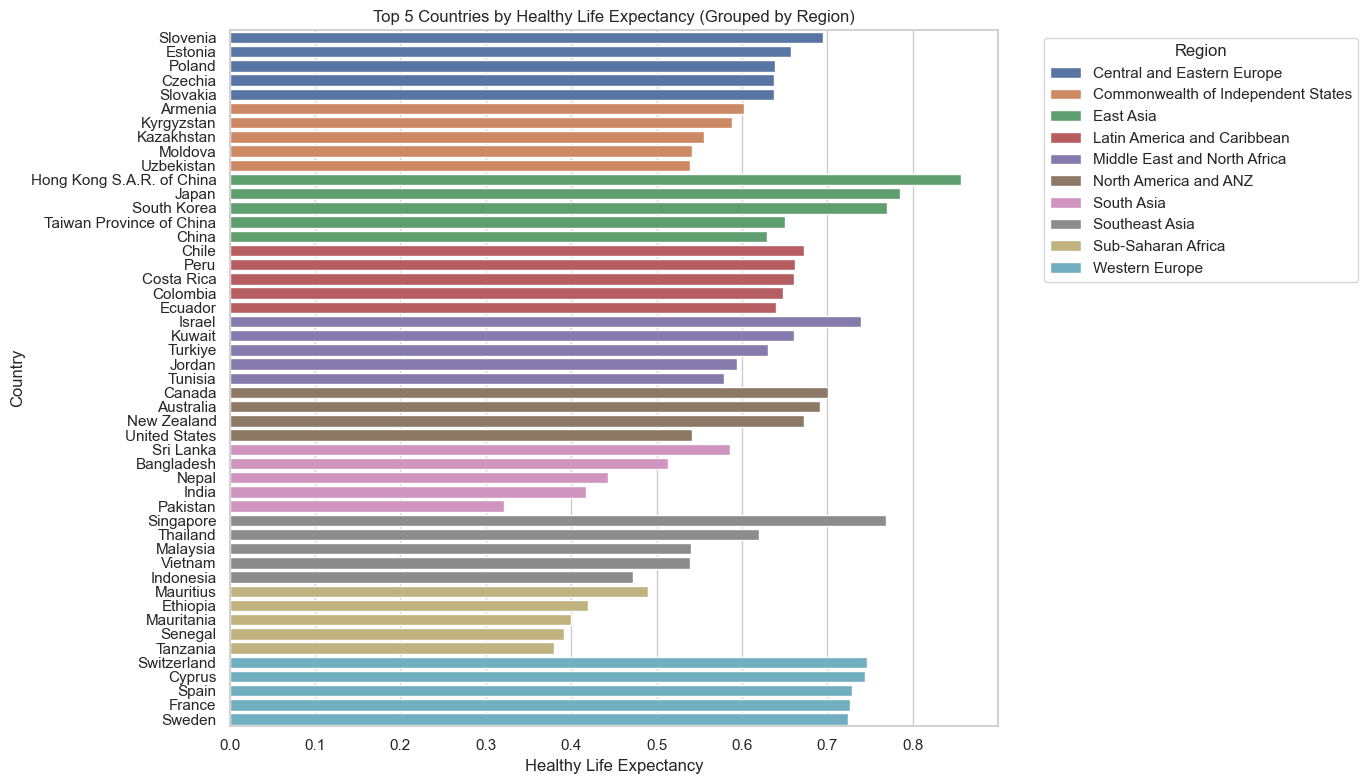

In [225]:
# Top 5 countries with highest healthy life expectancy, grouped by region

top5_by_region = data.groupby('Regional indicator').apply(lambda x: x.nlargest(5, 'Healthy life expectancy')).reset_index(drop=True)

plt.figure(figsize=(14,8))
sns.barplot(
    data=top5_by_region,
    x='Healthy life expectancy',
    y='Country name',
    hue='Regional indicator',
    dodge=False
)
plt.title('Top 5 Countries by Healthy Life Expectancy (Grouped by Region)')
plt.xlabel('Healthy Life Expectancy')
plt.ylabel('Country')
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

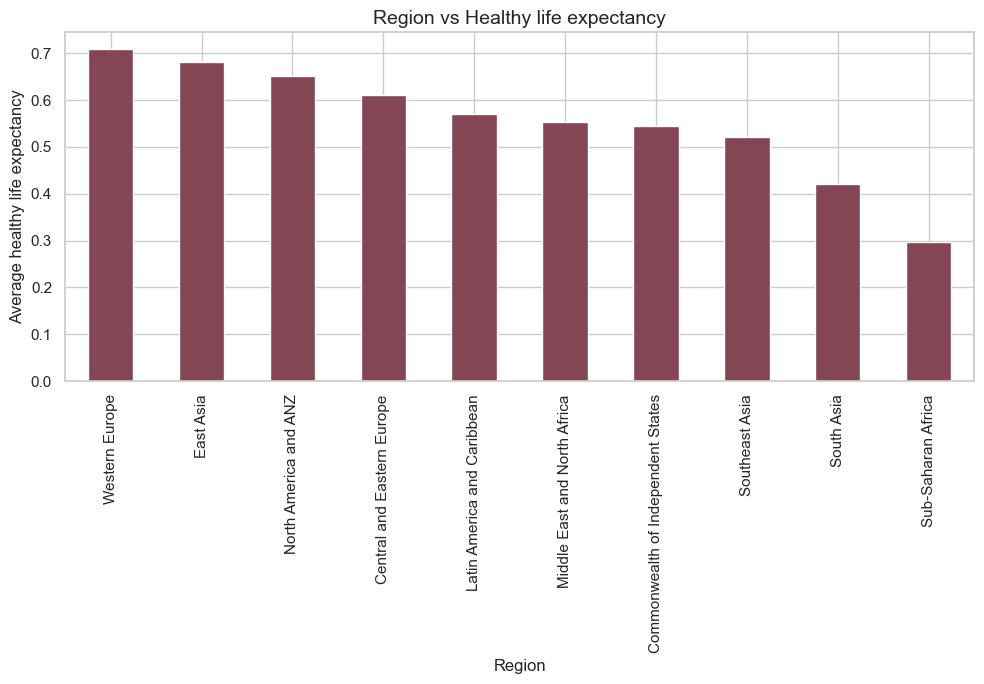

In [226]:
regional_gdp = data.groupby('Regional indicator')['Healthy life expectancy'].mean().sort_values(ascending=False)
plt.figure(figsize=(10,7))

regional_gdp.plot(kind='bar', color='#844555')

plt.title("Region vs Healthy life expectancy", fontsize=14)
plt.xlabel("Region")
plt.ylabel("Average healthy life expectancy")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

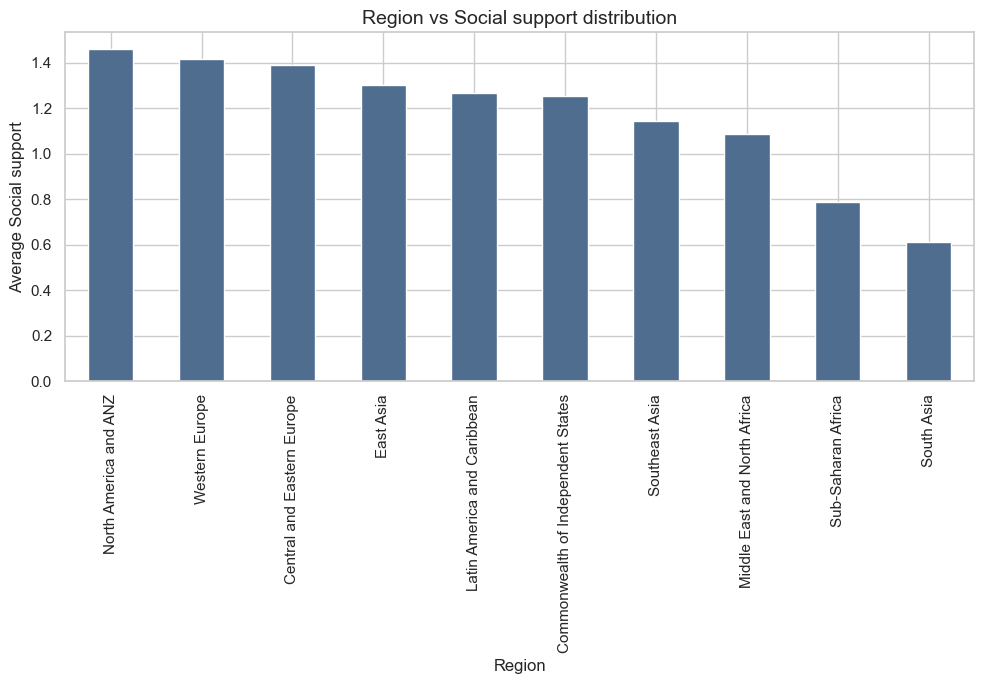

In [227]:
regional_gdp = data.groupby('Regional indicator')['Social support'].mean().sort_values(ascending=False)
plt.figure(figsize=(10,7))

regional_gdp.plot(kind='bar', color='#4f6d8f')

plt.title("Region vs Social support distribution", fontsize=14)
plt.xlabel("Region")
plt.ylabel("Average Social support")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Now we move into a deeper level of analysis by focusing on one specific numerical feature: the Healthy life expectancy score. This variable reflects the overall health conditions and life expectancy of individuals within each country, making it a key indicator of well-being and quality of life.

The goal of this step is to identify the top 10 countries with the highest healthy life expectancy scores. By doing this, we can highlight which countries are performing best in terms of health outcomes and longevity. This analysis can reveal patterns related to healthcare systems, living standards, nutrition, and social conditions that contribute to longer and healthier lives.

To achieve this, the dataset will be sorted in descending order based on the Healthy life expectancy column. Then, the top 10 countries will be selected. Since Country name is a categorical variable, it will be used here as a label to clearly identify each country associated with its score.

This analysis is useful because:

* It helps compare global health performance across countries
* It highlights leading nations in terms of well-being
* It can provide insights into policies or conditions that promote longer, healthier lives

In [228]:
top_10_health = data.sort_values(by="Healthy life expectancy", ascending=False).head(10)
print(top_10_health[["Country name", "Healthy life expectancy"]])

                 Country name  Healthy life expectancy
85  Hong Kong S.A.R. of China                    0.857
50                      Japan                    0.785
51                South Korea                    0.770
29                  Singapore                    0.769
8                 Switzerland                    0.747
49                     Cyprus                    0.744
4                      Israel                    0.740
35                      Spain                    0.729
26                     France                    0.727
3                      Sweden                    0.724


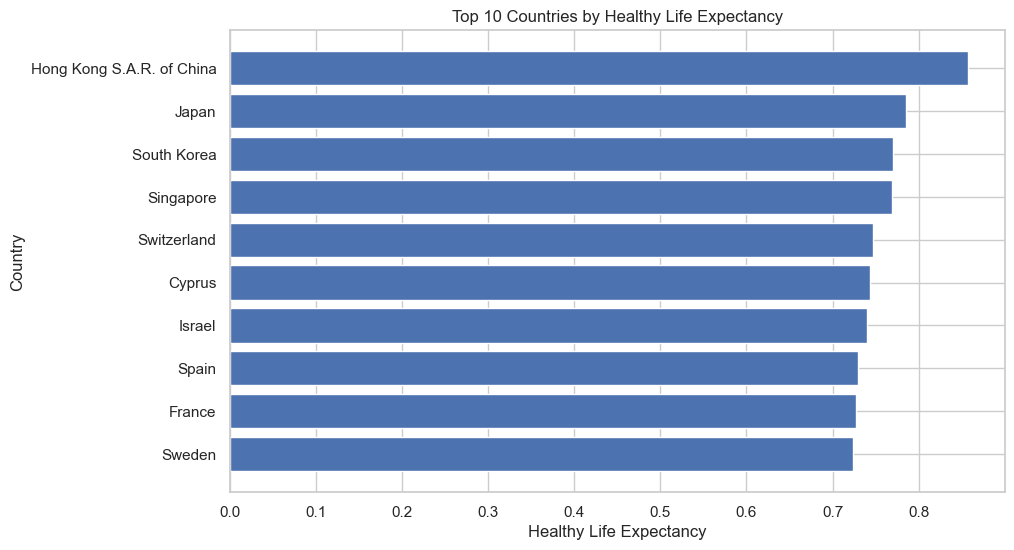

In [229]:
top_10_health = data.sort_values(by="Healthy life expectancy", ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(top_10_health["Country name"], top_10_health["Healthy life expectancy"])
plt.xlabel("Healthy Life Expectancy")
plt.ylabel("Country")
plt.title("Top 10 Countries by Healthy Life Expectancy")
plt.gca().invert_yaxis()  # Highest at the top
plt.show()

### Pairplot for Numerical Features

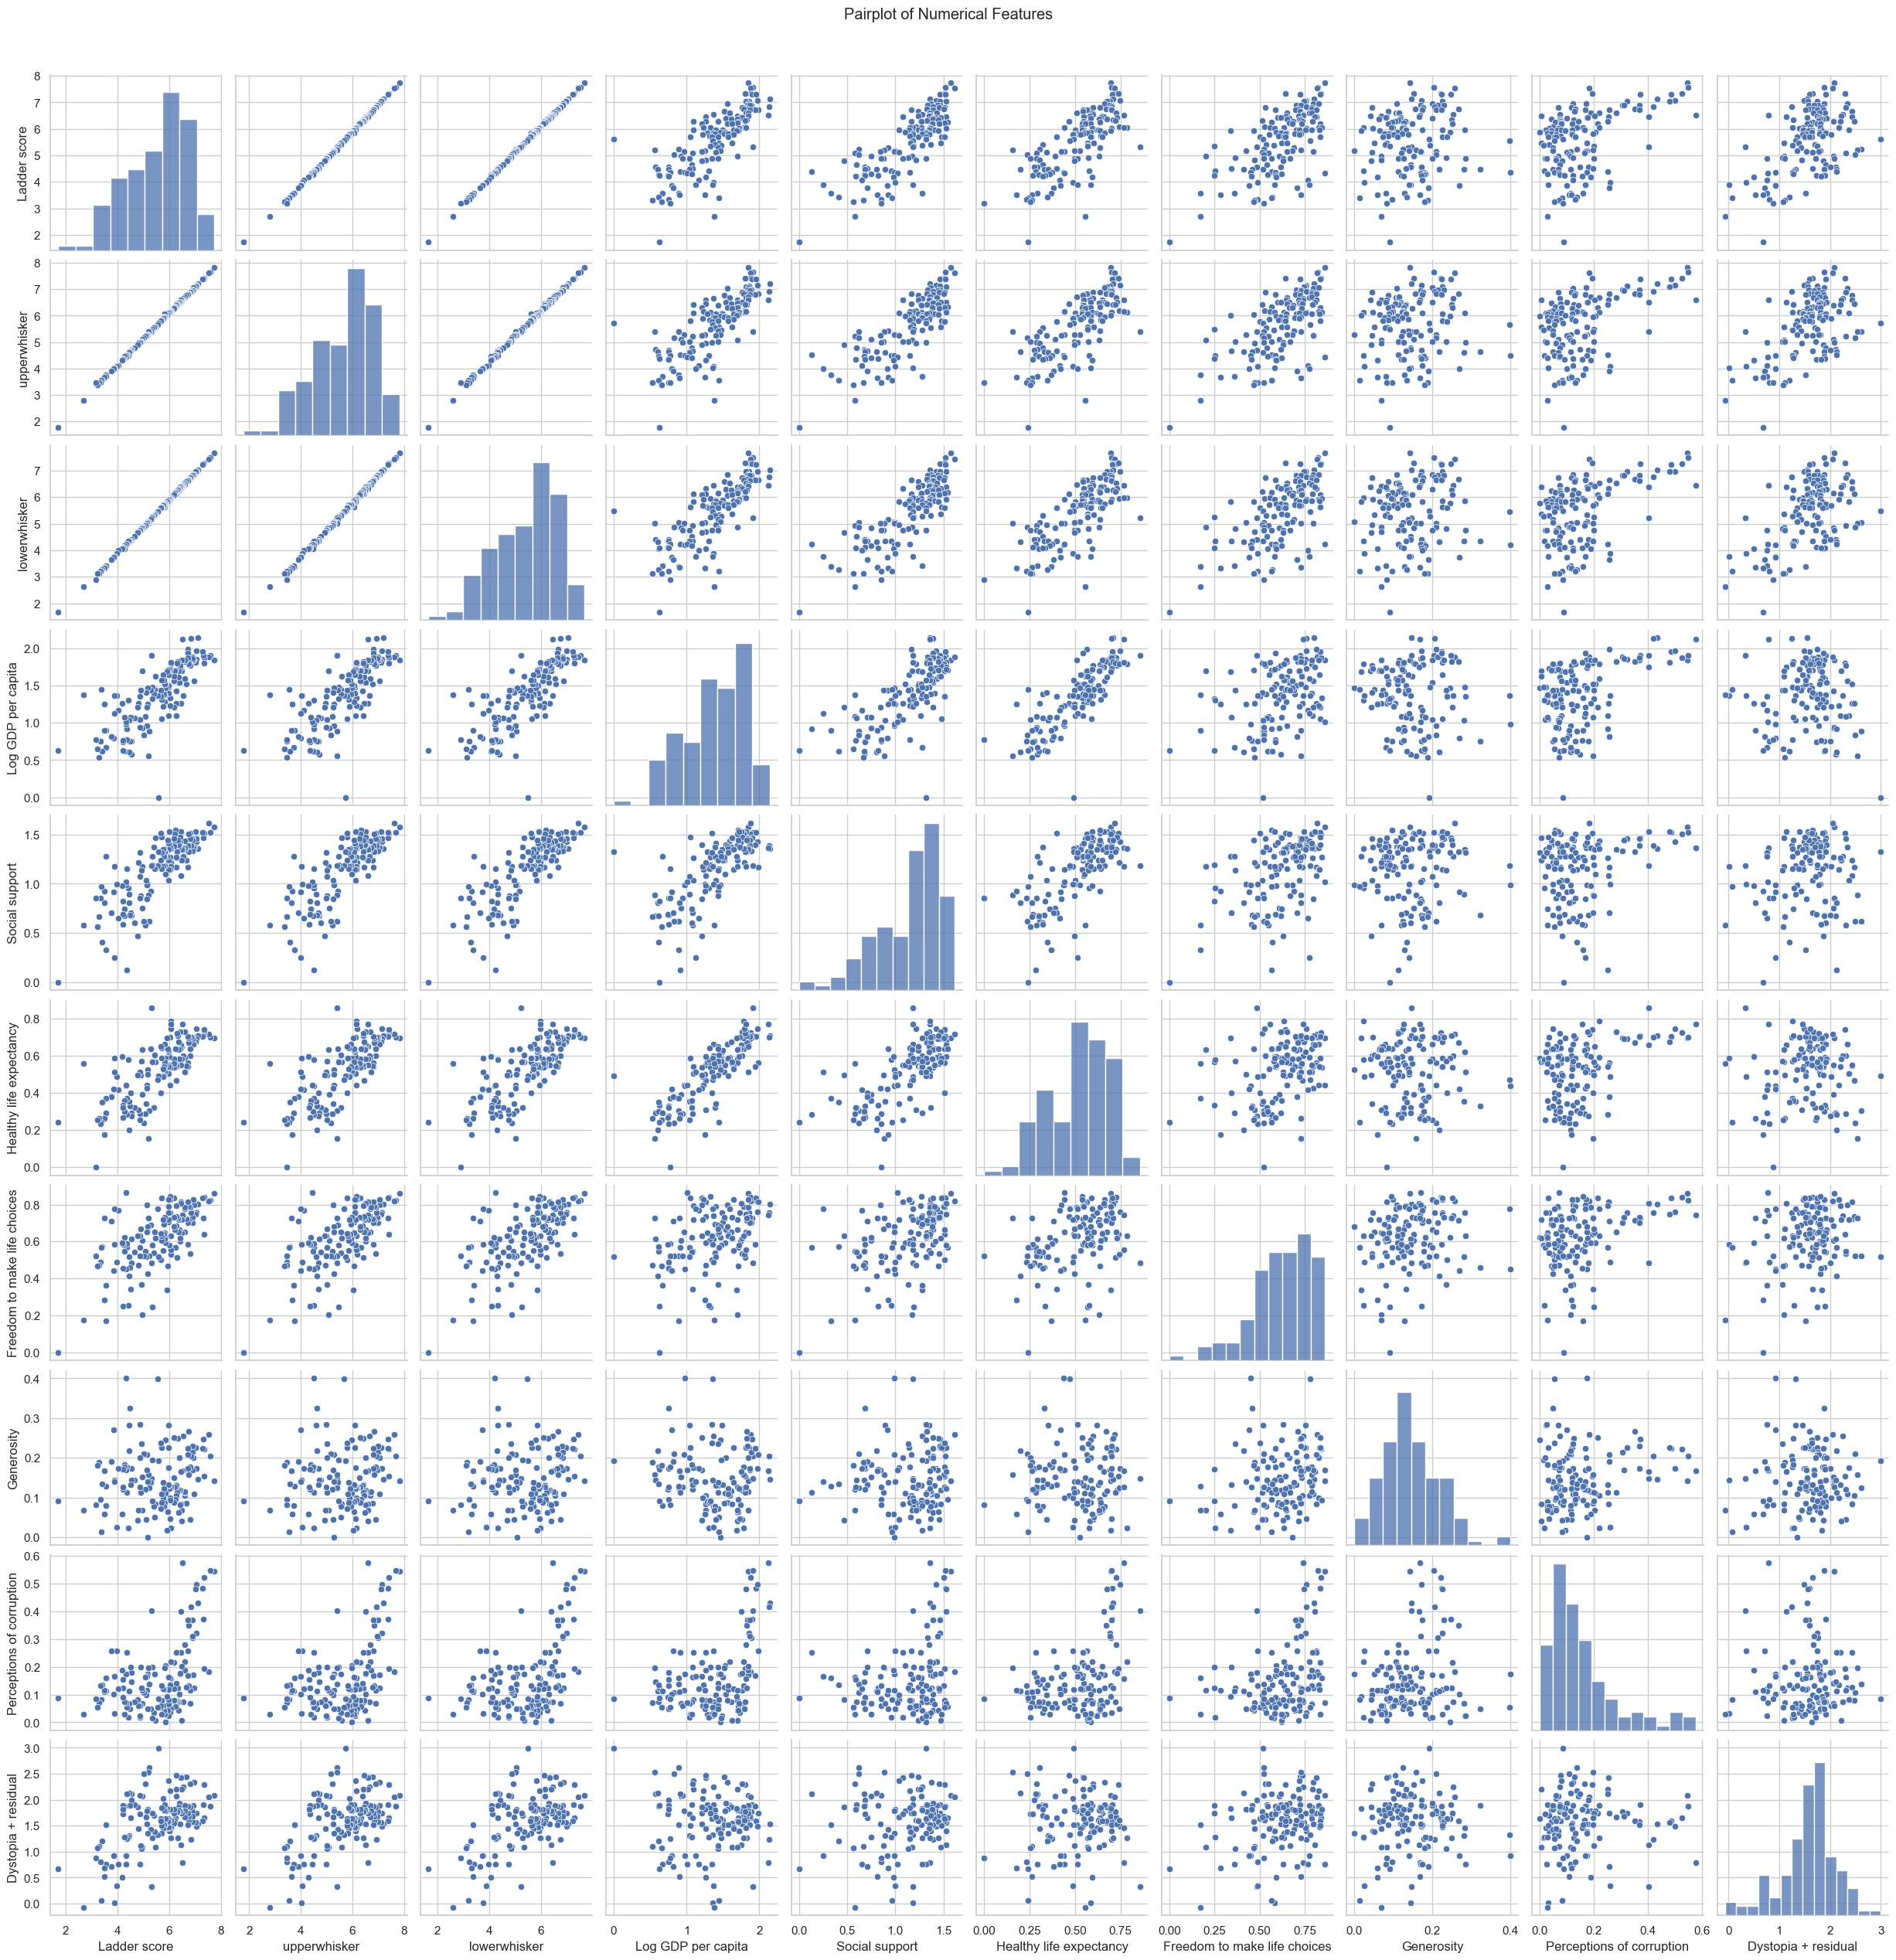

In [230]:
sns.pairplot(data[numerical_features])
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

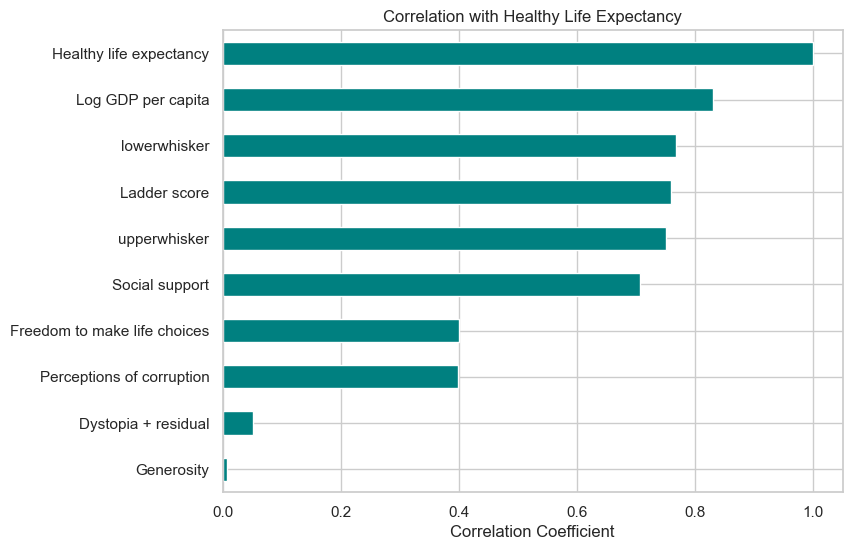

In [231]:
corr_with_target = data[numerical_features].corrwith(data['Healthy life expectancy']).sort_values()
plt.figure(figsize=(8, 6))
corr_with_target.plot(kind='barh', color='teal')
plt.title('Correlation with Healthy Life Expectancy')
plt.xlabel('Correlation Coefficient')
plt.show()

## Let Compare Spearman and Peason Correlation methods

__Simple Intuition__
* **Pearson** → “Do these variables move in a straight line together?”
* **Spearman** → “Do these variables move in the same direction overall?”

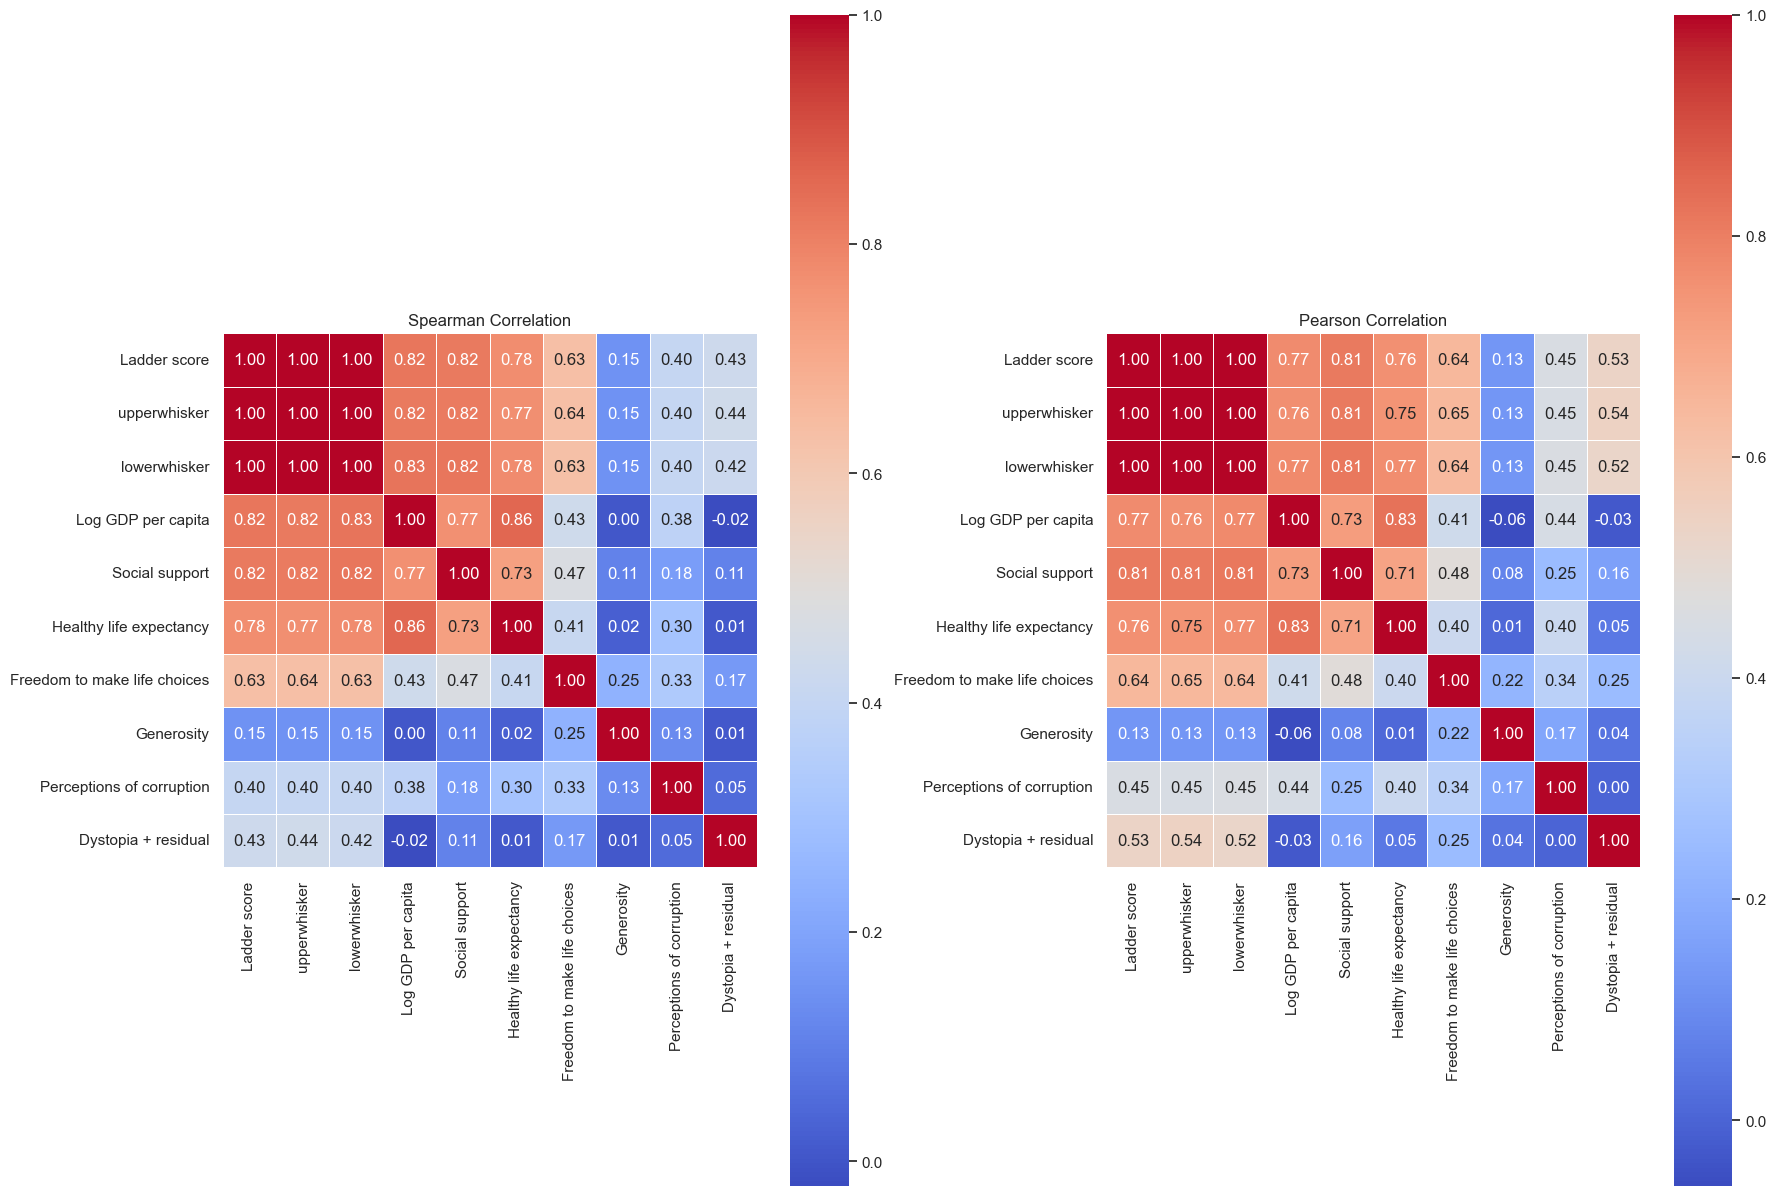

In [232]:
# Select only numerical columns from your DataFrame
corr_spearman = data[numerical_features].corr(method='spearman')
corr_pearson = data[numerical_features].corr(method='pearson')

# Set style for better visuals
sns.set(style="white")

# Create figure with better proportions
fig, ax = plt.subplots(1, 2, figsize=(18, 15))

# Plot heatmap with improvements
sns.heatmap(
    corr_spearman,
    annot=True,
    fmt=".2f",              # Limit decimals
    cmap="coolwarm",        # Better color contrast
    linewidths=0.5,         # Add spacing between cells
    linecolor='white',
    cbar_kws={"shrink": 0.8},  # Adjust color bar size
    square=True,  
    ax=ax[0]# Make cells square for alignment
)

# Improve title and layout
ax[0].set_title("Spearman Correlation")
ax[0].tick_params(axis='x', rotation=90)
ax[0].tick_params(axis='y', rotation=0)

# Plot heatmap with improvements
sns.heatmap(
    corr_pearson,
    annot=True,
    fmt=".2f",              # Limit decimals
    cmap="coolwarm",        # Better color contrast
    linewidths=0.5,         # Add spacing between cells
    linecolor='white',
    cbar_kws={"shrink": 0.8},  # Adjust color bar size
    square=True,
    ax=ax[1]# Make cells square for alignment
)

# Improve title and layout
ax[1].set_title("Pearson Correlation" )
ax[1].tick_params(axis='x', rotation=90)
ax[1].tick_params(axis='y', rotation=0)

# Ensure everything fits nicely (important for export/print)
# Save for CV / report use
plt.savefig("correlation_comparison.pdf", dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

## 📊 Overview

The image presents two correlation matrices:

* **Spearman correlation** (left) → captures *monotonic relationships* (rank-based)
* **Pearson correlation** (right) → captures *linear relationships*


##  Key Insights

### Strongest Drivers of Happiness (Ladder Score)

The **Ladder score** shows consistently high positive correlations with:

* **Log GDP per capita** (~0.77–0.82)
* **Social support** (~0.81–0.82)
* **Healthy life expectancy** (~0.75–0.78)

👉 Interpretation:
Countries with higher income, better social systems, and longer healthy lives tend to report **higher happiness levels**.


###  Moderate Influences

* **Freedom to make life choices** (~0.63–0.65)
* **Perceptions of corruption** (~0.40–0.45)

👉 These variables still matter, but their influence is **less dominant** compared to economic and health factors.


### Strong Relationships Between Predictors

* **Log GDP per capita ↔ Healthy life expectancy** (~0.83–0.86)
* **Log GDP per capita ↔ Social support** (~0.73–0.77)

👉 Insight:

* Wealthier countries tend to have:

  * Better healthcare systems
  * Stronger social structures


## Spearman vs Pearson

* Both matrices show **very similar patterns**
* Slight differences indicate:

  * Relationships are **mostly linear**
  * Few strong non-linear effects

##  Final Takeaways

1. **Top predictors of happiness:**

   * Economic strength (GDP)
   * Social support
   * Health (life expectancy)

2. **Secondary factors:**

   * Freedom and corruption perception

3. **Minimal impact:**

   * Generosity






## Here are a few line Explanation of the above:


### General Interpretation

* *“Both Pearson and Spearman correlation matrices show consistent relationships among variables, indicating predominantly linear associations with minimal influence from outliers.”*


### If Results Are Very Similar

* *“The similarity between Pearson and Spearman correlations suggests that the relationships between variables are largely linear and stable across the dataset.”*


### ✅ If Strong Correlations Found

* *“Several strong positive and negative correlations were identified, highlighting key relationships that may be useful for feature selection and predictive modeling.”*


**From the above graph we can the Health life expection and GDP per capital are highly correlated in both Peason and Spearman graphics** 

* Spearman correlation 86%
* Pearson correlation 83%

We'll look at this features more closely feather in this project

In [233]:
## Let's check how the data are correlated
df_num_corr = data[numerical_features].corr(method='spearman')['Healthy life expectancy'] # -1 means that the latest row is price
top_features = df_num_corr[abs(df_num_corr) > 0.2].sort_values(ascending=False) #displays pearsons correlation coefficient 
print("There is {} strongly correlated values with Healthy life expectancy:\n{}".format(len(top_features), top_features))

There is 8 strongly correlated values with Healthy life expectancy:
Healthy life expectancy         1.000000
Log GDP per capita              0.859234
lowerwhisker                    0.779814
Ladder score                    0.776154
upperwhisker                    0.770514
Social support                  0.725592
Freedom to make life choices    0.411478
Perceptions of corruption       0.304243
Name: Healthy life expectancy, dtype: float64


## Label Encoding
Labelencoding is a technique used in machine learning to convert categorical variables into numerical variables. It is a way to represent categorical data in a numerical format that can be used by machine learning algorithms. Label encoding is a type of encoding where each unique category is assigned a unique integer value. The most common method of label encoding is the use of the LabelEncoder class from the sklearn.preprocessing module in Python.


In [234]:

##Converting category labels into numerical using LabelEncoder
from sklearn.preprocessing import LabelEncoder
label = LabelEncoder()
label.fit(data['Regional indicator'].drop_duplicates())
data['Regional indicator'] = label.transform(data['Regional indicator'])

data.dtypes

Country name                     object
Regional indicator                int64
Ladder score                    float64
upperwhisker                    float64
lowerwhisker                    float64
Log GDP per capita              float64
Social support                  float64
Healthy life expectancy         float64
Freedom to make life choices    float64
Generosity                      float64
Perceptions of corruption       float64
Dystopia + residual             float64
dtype: object

## Linear Regression Using One Explanatory Variable
In this example, we will try to predict Heathy life expectancy withLog GDP per capita using Linear Regression:


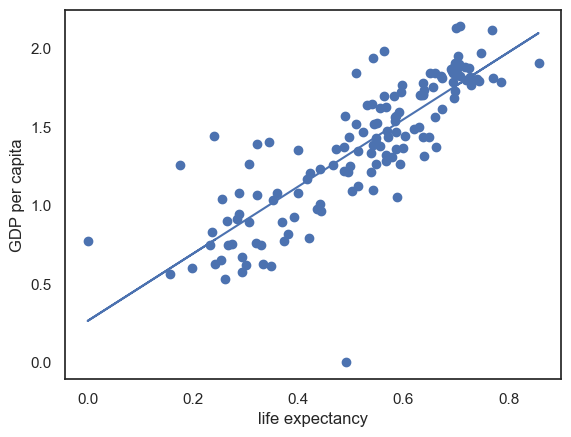

In [235]:
from scipy import stats

x = data["Healthy life expectancy"]
y = data["Log GDP per capita"]

slope, intercept, r, p, std_err = stats.linregress(x, y)

def myfunc(x):
 return slope * x + intercept

mymodel = list(map(myfunc, x))

plt.scatter(x, y)
plt.plot(x, slope * x + intercept)
plt.xlabel("life expectancy")
plt.ylabel ("GDP per capita")
plt.show()


## Explanation

* Get important key values with: slope, intercept, r, p, std_err = stats.linregress(x, y)
* Create a function that uses the slope and intercept values to return a new value. This new value represents where on the y-axis the corresponding x value will be placed
* Run each value of the x array through the function. This will result in a new array with new values for the y-axis: mymodel = list(map(myfunc, x))
* Draw the original scatter plot: plt.scatter(x, y)
* Draw the line of linear regression: plt.plot(x, mymodel)
* Define maximum and minimum values of the axis
Label the axis: **"life expectancy"** and **"GDP per capita"**

*Let compare the prediction of one feature vs all the features performance on Healthy life expectancy prediction*

In [236]:
import statsmodels.formula.api as smf

model = smf.ols('Q("Healthy life expectancy") ~ Q("Log GDP per capita")', data=data)
results = model.fit()
print(results.summary())

                                 OLS Regression Results                                 
Dep. Variable:     Q("Healthy life expectancy")   R-squared:                       0.689
Model:                                      OLS   Adj. R-squared:                  0.687
Method:                           Least Squares   F-statistic:                     306.2
Date:                          Sat, 11 Apr 2026   Prob (F-statistic):           7.58e-37
Time:                                  20:13:06   Log-Likelihood:                 136.00
No. Observations:                           140   AIC:                            -268.0
Df Residuals:                               138   BIC:                            -262.1
Df Model:                                     1                                         
Covariance Type:                      nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
------------------

**Coef** is short for coefficient. It is the output of the linear regression function.
The linear regression function can be rewritten mathematically as:

Healthy life expectancy = 0.3221 * Q("Log GDP per capita") + 0.0768
These numbers means:

* If ALog GDP per capita increases by 1, life expectancy increases by 0.3296 (or 0,3 rounded)
* If GDP per capita = 0, life expectancy is equal to 0.0768 (or 0.08 rounded).
* Remember that the intercept is used to adjust the model's precision of predicting!
* we have p value of 0.004
* Rsquare of 69%
  
I don't think that this is a good model, but let's go on with this thought?

## Hypothesis Testing and P-value

The null hypothesis can either be rejected or not.

If we reject the null hypothesis, we conclude that it exist a relationship between Log GDP per capita and life expectancy. The P-value is used for this conclusion.

A common threshold of the P-value is 0.05.

Note: A P-value of 0.05 means that 5% of the times, we will falsely reject the null hypothesis. It means that we accept that 5% of the times, we might falsely have concluded a relationship.

If the P-value is lower than 0.05, we can reject the null hypothesis and conclude that it exist a relationship between the variables.

However, the P-value of Log GDP per capita is 0.004. So, we conclude a relationship between Log GDP per capita and life expectancy.

It means that there is a 0.4% chance that the true coefficient of Log GDP per capita is zero.

The intercept is used to adjust the regression function's ability to predict more precisely. It is therefore uncommon to interpret the P-value of the intercept.

R-Squared value of 69%, which means that the linear regression function line does fit the data well.

## Let define the linear regression function in Python to perform predictions.

What is life expectancy if Log GDP per capita is: 0.5, 0.8, 1.2, 1.5, 1.7?

In [237]:
def Predict_life_expectancy(LogGDPpercapita):
 return(0.3221 *  LogGDPpercapita  + 0.0768)
 
#Try some different values:
print(Predict_life_expectancy(0.5))
print(Predict_life_expectancy(0.8))
print(Predict_life_expectancy(1.2))
print(Predict_life_expectancy(1.5))
print(Predict_life_expectancy(1.7))

0.23785
0.33448
0.46331999999999995
0.55995
0.62437


## What realy contries to a long life expectancy

In [238]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics

X = data.drop(["Country name","Healthy life expectancy","upperwhisker", "lowerwhisker"], axis=1)
y = data["Healthy life expectancy"]
#train test split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.4, random_state=123)
# LinearRegression Model
Lr = LinearRegression()
Lr.fit(X_train, y_train)

# Assuming lr is your fitted linear regression model and X is your feature DataFrame
coef = Lr.coef_  # Get the coefficients from the linear regression model
column = X.columns  # Get the feature names

# Create a DataFrame with feature names and their corresponding coefficients
df_ = pd.DataFrame({'Feature': column, 'Coefficient': coef})

# Reset the index if needed (not necessary here since we are creating a new DataFrame)
df_ = df_.reset_index(drop=True)

# Display the DataFrame
print(df_)

                        Feature  Coefficient
0            Regional indicator     0.000014
1                  Ladder score     0.999059
2            Log GDP per capita    -0.998082
3                Social support    -1.000209
4  Freedom to make life choices    -0.999037
5                    Generosity    -0.996784
6     Perceptions of corruption    -0.999419
7           Dystopia + residual    -0.998922


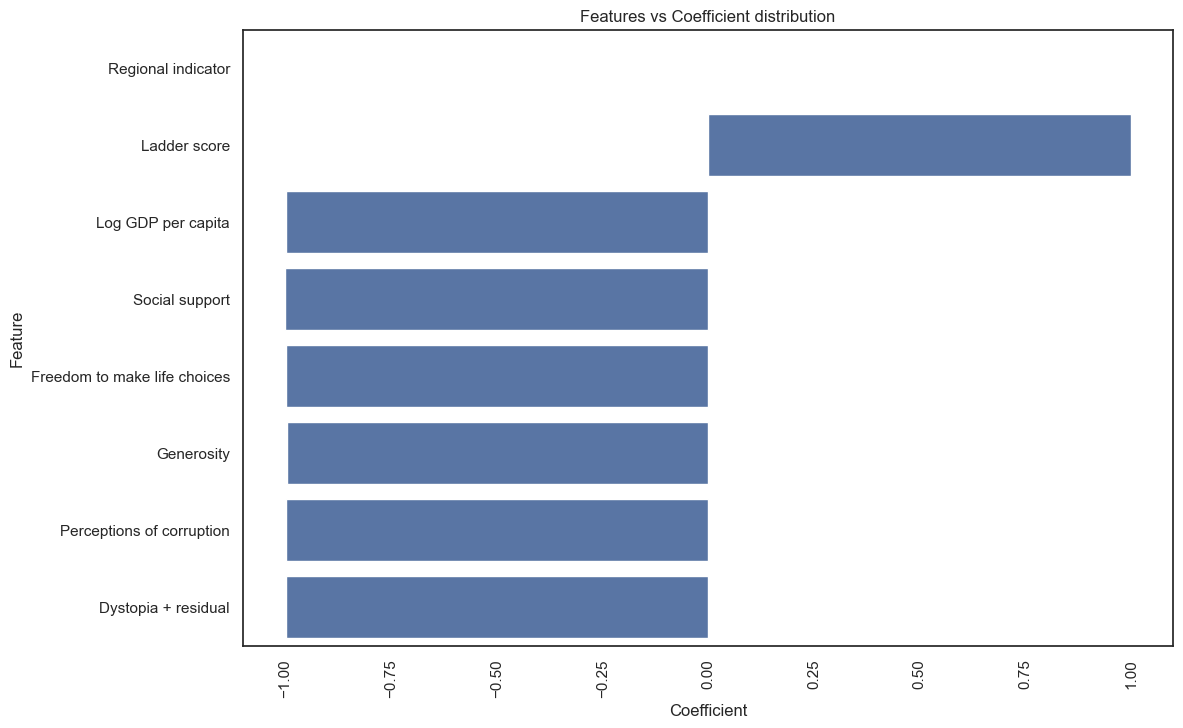

In [239]:
plt.figure(figsize=(12,8))
sns.barplot(data= df_, x="Coefficient", y="Feature")
plt.title('Features vs Coefficient distribution')
plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.xticks(rotation=90)
plt.show()

## Model evaluation and prediction

In [240]:
import numpy as np

y_pred = Lr.predict(X_test)
#r2_score
linear_score = metrics.r2_score(y_test, y_pred)

def Evaluation(x_test, y_test, model) :
  y_pred = model.predict(x_test)
  mse = metrics.mean_absolute_error(y_test, y_pred)
  msqe = metrics.mean_squared_error(y_test, y_pred)
  r2_score = metrics.r2_score(y_test, y_pred)
  rmse = np.sqrt(metrics.mean_squared_error(y_test, y_pred))

  print("mean_absolute_error : ", mse)
  print("mean_squared_error : ", msqe)
  print("root_mean_absolute_error : ", rmse)
  print("r2_score    : ", r2_score)
#Evalution 
Evaluation(X_test, y_test, Lr)

mean_absolute_error :  0.0007125022636265539
mean_squared_error :  8.21270588623069e-07
root_mean_absolute_error :  0.0009062398074588585
r2_score    :  0.9999687120905413


## Compare the model prediction

In [241]:
def compare(y_test, y_pred) :
  compare = pd.DataFrame()
  compare["Actual life expectancy"] = y_test
  compare["Predict"] = y_pred

  return compare
    
compare(y_test, y_pred)

,Actual life expectancy,Predict
106,0.495,0.495642
128,0.513,0.514885
125,0.417,0.416627
45,0.564,0.564962
31,0.583,0.582174
122,0.333,0.335150
75,0.587,0.586943
35,0.729,0.728979
4,0.740,0.740063
131,0.370,0.370780


## Predicted vs Actual Plot

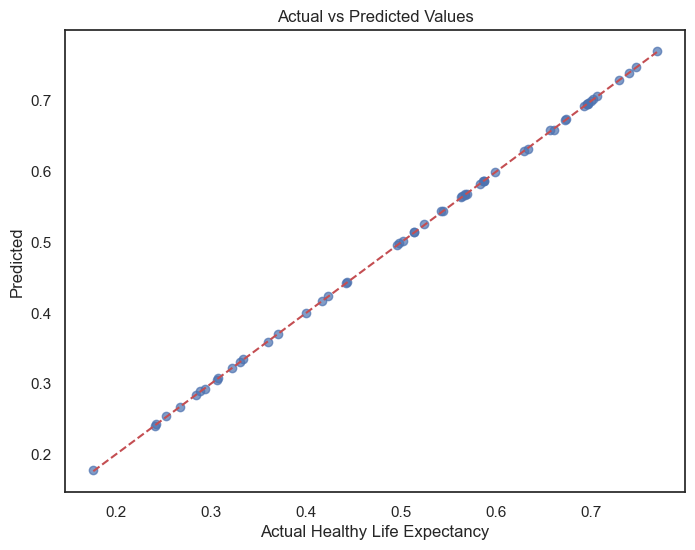

In [242]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel('Actual Healthy Life Expectancy')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted Values')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

## Interpretation
### The model demonstrates extremely high accuracy
> This aligns with:
* High R² score
* Near-zero residuals


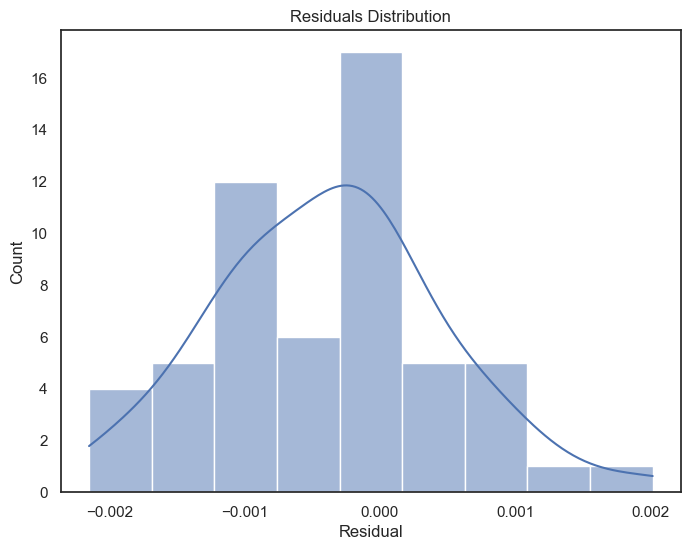

In [243]:
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True)
plt.title('Residuals Distribution')
plt.xlabel('Residual')
plt.show()

### Insight

From the correlation analysis and model behavior observed in the graph, the results suggest that the model demonstrates a well-fitted and comprehensive training process. One key indicator of this is the distribution of residuals, which appears to be heavily concentrated around values close to 0 (e.g., 0 and -0.001).

Residuals represent the difference between the actual values and the predicted values. When these residuals are very close to zero, it indicates that the model’s predictions are highly accurate. In this case, the clustering of residuals around zero suggests that the predicted values closely match the actual observations, meaning the model is capturing the underlying patterns in the data effectively.

This near-zero residual distribution implies:

* High predictive accuracy, as errors are minimal
* Low bias in the model, meaning it is not consistently overestimating or underestimating
* A strong alignment between input features (e.g., GDP, social support, health) and the target variable

## Feature importance of Random Forest Regressor Model

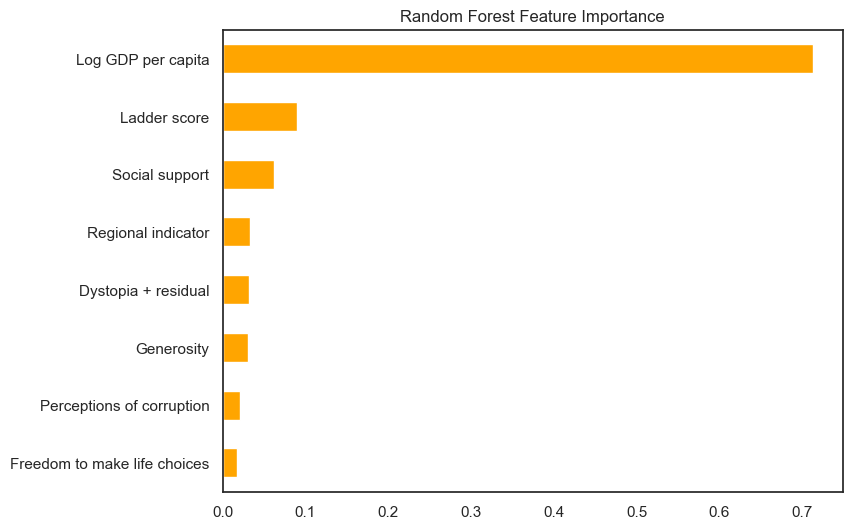

In [244]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=123)
rf.fit(X_train, y_train)
importances = rf.feature_importances_
feat_importance = pd.Series(importances, index=X.columns).sort_values()
feat_importance.plot(kind='barh', figsize=(8, 6), color='orange')
plt.title('Random Forest Feature Importance')
plt.show()

## Summary

In this project, we explored the World Happiness Score dataset with a focus on understanding the factors that influence healthy life expectancy across countries and regions. We performed comprehensive data cleaning, exploratory data analysis, and visualizations to uncover patterns and relationships in the data. Key steps included:

- Loading and cleaning the dataset, handling missing values and duplicates
- Exploring the distribution of features and identifying categorical and numerical variables
- Visualizing relationships between healthy life expectancy, GDP per capita, social support, and other features
- Comparing correlation methods (Pearson and Spearman) to understand linear and monotonic relationships
- Building and evaluating linear regression models to predict healthy life expectancy
- Analyzing feature importance using both linear regression coefficients and Random Forest models
- Visualizing the top countries by healthy life expectancy, grouped by region

## Conclusion

Our analysis revealed that economic strength (GDP per capita), social support, and health-related factors are the strongest predictors of happiness and healthy life expectancy. Regions with higher GDP and better social systems tend to have longer healthy life expectancies. The relationships between variables are largely linear, as shown by the similarity between Pearson and Spearman correlations. While linear regression provides useful insights, more complex models like Random Forests can further highlight the importance of different features.

Overall, the project demonstrates the value of data-driven approaches in understanding global well-being and the factors that contribute to a healthier, happier society.